# Analyse du modèle 

In [1]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd 
import joblib
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import precision_score, recall_score, confusion_matrix


In [12]:
df = pd.read_csv("../data/processed/processed_data.csv")

y = (df['arr_delay']>0).astype(int)

model = joblib.load("../models/lightgbm_model.pkl")
selected_features = joblib.load("../models/selected_features_LGB.pkl")
encoders = joblib.load("../models/encoders.pkl")

/opt/anaconda3/envs/flights-mlops/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/flights-mlops/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dataset shape: (9862, 41)
Nombre de features sélectionnées : 21
Répartition des classes :
arr_delay
0    7200
1    2662
Name: count, dtype: int64

Proportion des classes :
arr_delay
0    0.730075
1    0.269925
Name: proportion, dtype: float64


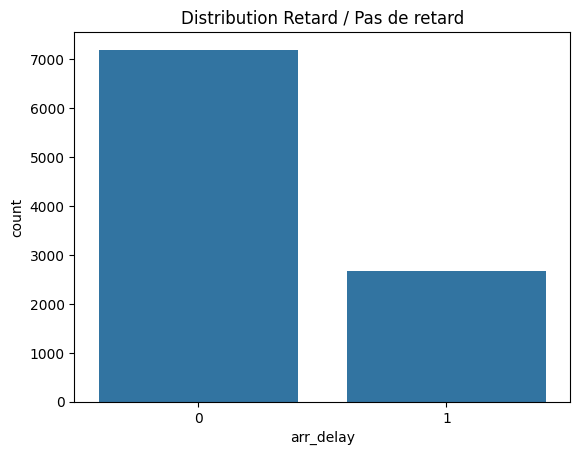

In [13]:
print("Dataset shape:", df.shape)
print("Nombre de features sélectionnées :", len(selected_features))

print("Répartition des classes :")
print(y.value_counts())
print("\nProportion des classes :")
print(y.value_counts(normalize=True))

sns.countplot(x=y)
plt.title("Distribution Retard / Pas de retard")
plt.show()

In [14]:
# calcul des médianes 
num_cols = df[selected_features].select_dtypes(include='number').columns
median_values = df[num_cols].median()


print("Médianes des features numériques :")
print(median_values.head())


Médianes des features numériques :
crs_dep_min          28.0
dep_min              30.5
dep_hour             13.0
crs_dep_hour         13.0
op_unique_carrier     9.0
dtype: float64


Probabilité min: 0.04566568439913148
Probabilité max: 0.9902822915198595
Probabilité moyenne: 0.3432216325115885


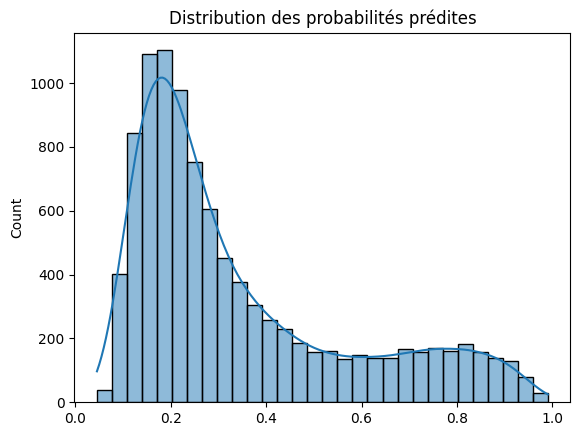

In [15]:
X = df[selected_features]
proba = model.predict_proba(X)[:,1]

print("Probabilité min:", proba.min())
print("Probabilité max:", proba.max())
print("Probabilité moyenne:", proba.mean())

sns.histplot(proba, bins=30, kde=True)
plt.title("Distribution des probabilités prédites")
plt.show()

In [16]:
threshold = 0.5
pred = (proba > threshold).astype(int)

accuracy = (pred == y).mean()
print("Accuracy global :", accuracy)
print("Precision :", precision_score(y, pred))
print("Recall :", recall_score(y, pred))
print("Confusion matrix :\n", confusion_matrix(y, pred))


Accuracy global : 0.8760900425877104
Precision : 0.8333333333333334
Recall : 0.67618332081142
Confusion matrix :
 [[6840  360]
 [ 862 1800]]


In [23]:
sample_input = {
    "crs_dep_hour": 14,
    "crs_dep_min": 30,
    "crs_arr_hour": 16,
    "crs_arr_min": 10,
    "fl_month": 7,
    "fl_day": 15,
    "fl_dayofweek": 0,
    "is_weekend": 0,
    "op_carrier_fl_num": 1234,
    "season": encoders['season'].transform(['summer'])[0],
    "origin_city_name": encoders['origin_city_name'].transform(['Phoenix, AZ'])[0] 
                        if 'Phoenix, AZ' in encoders['origin_city_name'].classes_ else median_values.get('origin_city_name', 0),
    "origin_state_nm": encoders['origin_state_nm'].transform(['Arizona'])[0] 
                        if 'Arizona' in encoders['origin_state_nm'].classes_ else median_values.get('origin_state_nm', 0),
    "dest_city_name": encoders['dest_city_name'].transform(['Nashville, TN'])[0] 
                        if 'Nashville, TN' in encoders['dest_city_name'].classes_ else median_values.get('dest_city_name', 0),
    "dest_state_nm": encoders['dest_state_nm'].transform(['Tennessee'])[0] 
                        if 'Tennessee' in encoders['dest_state_nm'].classes_ else median_values.get('dest_state_nm', 0)
}

In [24]:
for col in selected_features:
    if col not in sample_input:
        if col in median_values:
            sample_input[col] = median_values[col]
        else:
            sample_input[col] = 0  # fallback si médiane non disponible



In [25]:
X_sample = pd.DataFrame([sample_input])[selected_features]
pred_sample = model.predict(X_sample)[0]
proba_sample = model.predict_proba(X_sample)[0,1]

print("Prediction:", pred_sample)
print("Probability:", round(proba_sample,3))

Prediction: 1
Probability: 0.533


In [21]:
# Calculer les médianes des features numériques sélectionnées
num_cols = df[selected_features].select_dtypes(include='number').columns
median_values = df[num_cols].median()

# Sauvegarder pour l'API
joblib.dump(median_values, "../models/median_values.pkl")

['../models/median_values.pkl']

In [27]:
encoders = joblib.load("../models/encoders.pkl")


print("Origin cities connues :", encoders["origin_city_name"].classes_[:20])
print("Destination cities connues :", encoders["dest_city_name"].classes_[:20])

Origin cities connues : ['Aberdeen, SD' 'Abilene, TX' 'Aguadilla, PR' 'Akron, OH' 'Albany, NY'
 'Albuquerque, NM' 'Alexandria, LA' 'Allentown/Bethlehem/Easton, PA'
 'Amarillo, TX' 'Anchorage, AK' 'Appleton, WI' 'Arcata/Eureka, CA'
 'Asheville, NC' 'Ashland, WV' 'Aspen, CO' 'Atlanta, GA'
 'Atlantic City, NJ' 'Augusta, GA' 'Austin, TX' 'Bakersfield, CA']
Destination cities connues : ['Aberdeen, SD' 'Abilene, TX' 'Aguadilla, PR' 'Akron, OH' 'Albany, NY'
 'Albuquerque, NM' 'Alexandria, LA' 'Allentown/Bethlehem/Easton, PA'
 'Amarillo, TX' 'Anchorage, AK' 'Appleton, WI' 'Arcata/Eureka, CA'
 'Asheville, NC' 'Aspen, CO' 'Atlanta, GA' 'Atlantic City, NJ'
 'Augusta, GA' 'Austin, TX' 'Bakersfield, CA' 'Baltimore, MD']


/opt/anaconda3/envs/flights-mlops/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [29]:
df = pd.read_csv("../data/raw/flight_data_2024_sample.csv")

# Valeurs brutes
print("Nombre de villes d'origine uniques (brut) :", df['origin_city_name'].nunique())

# Après normalisation
def normalize_text(value):
    return value.strip().title()

print("Nombre de villes d'origine uniques (normalisées) :", 
      df['origin_city_name'].apply(normalize_text).nunique())

Nombre de villes d'origine uniques (brut) : 278
Nombre de villes d'origine uniques (normalisées) : 278


In [34]:
import joblib

encoders = joblib.load("../models/encoders.pkl")
print(f"Nombre de villes d'origine connues : {len(encoders['origin_city_name'].classes_)}")
print(f"Exemples de villes d'origine : {encoders['origin_city_name'].classes_[:150]}")

Nombre de villes d'origine connues : 277
Exemples de villes d'origine : ['Aberdeen, SD' 'Abilene, TX' 'Aguadilla, PR' 'Akron, OH' 'Albany, NY'
 'Albuquerque, NM' 'Alexandria, LA' 'Allentown/Bethlehem/Easton, PA'
 'Amarillo, TX' 'Anchorage, AK' 'Appleton, WI' 'Arcata/Eureka, CA'
 'Asheville, NC' 'Ashland, WV' 'Aspen, CO' 'Atlanta, GA'
 'Atlantic City, NJ' 'Augusta, GA' 'Austin, TX' 'Bakersfield, CA'
 'Baltimore, MD' 'Bangor, ME' 'Baton Rouge, LA' 'Belleville, IL'
 'Bellingham, WA' 'Bemidji, MN' 'Bend/Redmond, OR' 'Billings, MT'
 'Binghamton, NY' 'Birmingham, AL' 'Bismarck/Mandan, ND'
 'Bloomington/Normal, IL' 'Boise, ID' 'Boston, MA' 'Bozeman, MT'
 'Bristol/Johnson City/Kingsport, TN' 'Brownsville, TX' 'Buffalo, NY'
 'Burbank, CA' 'Burlington, VT' 'Casper, WY' 'Cedar Rapids/Iowa City, IA'
 'Champaign/Urbana, IL' 'Charleston, SC' 'Charleston/Dunbar, WV'
 'Charlotte Amalie, VI' 'Charlotte, NC' 'Charlottesville, VA'
 'Chattanooga, TN' 'Cheyenne, WY' 'Chicago, IL' 'Cincinnati, OH'
 'Clevela